# Live Coding Exercise: CSF Biomarker Exploration

## Scenario
BridgeBio is developing an antisense oligonucleotide (ASO) therapy targeting a CNS-expressed gene (Gene X) for a rare neurodevelopmental disease. The ASO is designed to reduce expression of Gene X in the central nervous system.

In this exercise, you are provided with **synthetic CSF omics data** from a small, Phase-1–style study:

- 20 subjects (≈12 ASO, 8 placebo)
- CSF collected at **baseline** and **week 4**
- For each CSF sample:
  - Study metadata (treatment, timepoint, batch, site, dose, etc.)
  - **CSF proteomics** (300 proteins, including the protein product of Gene X)
  - **CSF transcriptomics** (500 RNAs, including Gene X)

All data are pre-processed and stored in the `data/` directory.

---

## Goal
Explore whether there are **molecular changes in CSF** that could serve as **biomarkers of target engagement** for the ASO.

This is intentionally a *larger* problem than can be fully completed during the interview.  
We are interested in **your reasoning, prioritization, and communication**, not a polished solution.

Helpful considerations:
- How you orient yourself in the data
- How you form and refine hypotheses about ASO-related CSF shifts
- How you choose comparisons or summaries to evaluate target-engagement signals
- How you communicate what you see, what you trust, and what you'd do next

---

## Notes
- You are welcome to use any online/public resources you have available to you throughout this exercise.
- You are free to plot using **any library you prefer** (matplotlib and seaborn are already available).  
- You may find it useful to examine **baseline → week 4** changes and **ASO vs placebo** differences, but your analytical approach is flexible.
- Target markers:
  - **GENE001** (RNA target)
  - **PROT001** (protein target)
- It is expected that you will only partway through the analysis.  
  The goal is to understand **your approach**, not your throughput.

A strong end state (which you will unlikely reach today) would be:
- A short list of **candidate target-engagement biomarkers**,  
- With a brief justification (e.g., effect direction, treatment/timepoint pattern, link to mechanism).

---

## Getting Started
Load the data however you prefer. A minimal example is provided below.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

meta = pd.read_csv("data/meta.csv")
prot = pd.read_csv("data/proteome.csv")
rna  = pd.read_csv("data/transcriptome.csv")

print("Meta shape:", meta.shape)
print("Proteome shape:", prot.shape)
print("Transcriptome shape:", rna.shape)

meta.head()
#prot.head()
#rna.head()

#print("PROT001 present:", "PROT001" in prot.iloc[:, 0].values)
#print("GENE001 present:", "GENE001" in rna.iloc[:, 0].values)

Meta shape: (40, 9)
Proteome shape: (40, 301)
Transcriptome shape: (40, 501)


,sample_id,subject_id,treatment,timepoint,batch,site,age,sex,dose
0,SUBJ001_baseline,SUBJ001,ASO,baseline,B,3,44.2,M,100
1,SUBJ001_week4,SUBJ001,ASO,week4,A,2,43.6,M,50
2,SUBJ002_baseline,SUBJ002,placebo,baseline,A,1,50.5,M,0
3,SUBJ002_week4,SUBJ002,placebo,week4,A,2,42.3,M,0
4,SUBJ003_baseline,SUBJ003,placebo,baseline,A,2,53.5,F,0


In [28]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy import stats

In [29]:
import os; print(os.listdir('data/'))
DATA_DIR = "data"
META_PATH = os.path.join(DATA_DIR, "meta.csv")
RNA_PATH  = os.path.join(DATA_DIR, "transcriptome.csv")
PROT_PATH = os.path.join(DATA_DIR, "proteome.csv")


['README_data.txt', 'transcriptome.csv', 'proteome.csv', 'meta.csv']


In [30]:
## index the RNA and Proteomics matrix to have sample_id as index


def load_matrix_flexible(path: str) -> pd.DataFrame:
    """
    Returns samples x features with index=sample_id.
    """
    df = read_table(path)
     
    # Case B: sample_id column exists
    for c in df.columns:
        if c.lower() in ("sample_id", "sample", "sid"):
            df = df.set_index(c)
            df.index.name = "sample_id"
            return df.apply(pd.to_numeric, errors="coerce")

    # Case A: first col is feature IDs; transpose
    first_col = df.columns[0]
    if df[first_col].dtype == object:
        stacked = pd.to_numeric(df[df.columns[1:]].stack(), errors="coerce")
        numeric_ratio = stacked.notna().mean()
        if numeric_ratio > 0.8:
            feat_by_sample = df.set_index(first_col)
            sample_by_feat = feat_by_sample.T
            sample_by_feat.index.name = "sample_id"
            return sample_by_feat.apply(pd.to_numeric, errors="coerce")

    # fallback: assume already sample x feature
    if df.index.name != "sample_id":
        df.index.name = "sample_id"
    return df.apply(pd.to_numeric, errors="coerce")


In [31]:
rna_index = load_matrix_flexible(RNA_PATH)
rna_index.head()

prot_index = load_matrix_flexible(PROT_PATH)
prot_index.head()


,PROT001,PROT002,PROT003,PROT004,PROT005,PROT006,PROT007,PROT008,PROT009,PROT010,...,PROT291,PROT292,PROT293,PROT294,PROT295,PROT296,PROT297,PROT298,PROT299,PROT300
sample_id,,,,,,,,,,,,,,,,,,,,,
SUBJ001_baseline,-1.182308,-0.836964,0.328798,-0.500543,1.070062,0.058293,-1.124097,-0.225632,-0.625575,-0.786819,...,0.922111,1.069894,-0.700962,-0.916806,0.834798,0.057742,-0.119447,0.319717,0.266909,1.211268
SUBJ001_week4,-1.073224,0.803919,-0.405876,0.859612,0.389378,0.664438,-1.271799,-0.277857,1.746990,-1.510135,...,2.542946,0.655592,-0.227222,-0.304517,1.269143,0.449300,-0.608323,-1.272563,0.827995,-0.790142
SUBJ002_baseline,-0.584974,1.446307,-1.013546,0.871276,-1.203610,0.692281,0.392731,0.305772,-0.791066,0.454482,...,1.418170,-0.627680,-0.268584,-0.730444,-1.305063,1.394571,-2.772381,-0.856988,-0.604866,-0.025219
SUBJ002_week4,-1.406557,1.180769,-2.014845,-2.005613,-0.145892,-1.478711,0.031206,-0.981610,0.663572,-1.125520,...,-0.261203,-0.192454,-1.026001,-1.516853,-0.651902,0.397619,0.396952,0.376526,1.058709,-1.251881
SUBJ003_baseline,-0.315822,-0.122682,-2.820327,0.286396,0.032488,NaN,0.933447,0.870258,0.461983,-1.646675,...,-1.115559,1.223413,-0.335760,1.118285,1.205805,0.608395,-0.552277,1.006389,0.275711,0.106822


PCA (RNA PCA colored by batch): using 500 features


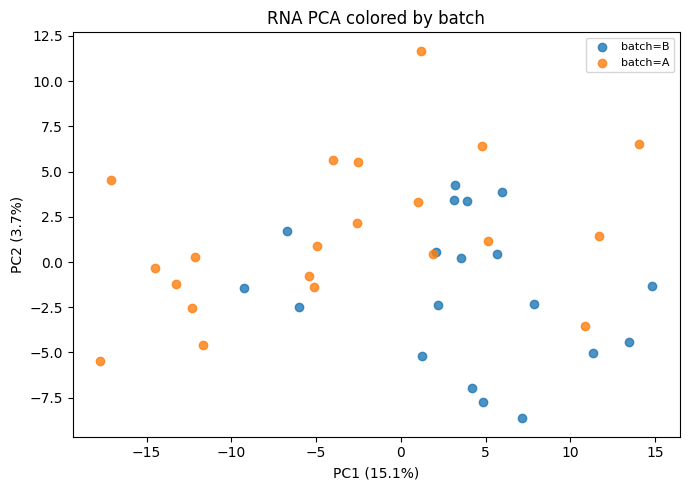

PCA (Proteomics PCA colored by batch): using 96 features


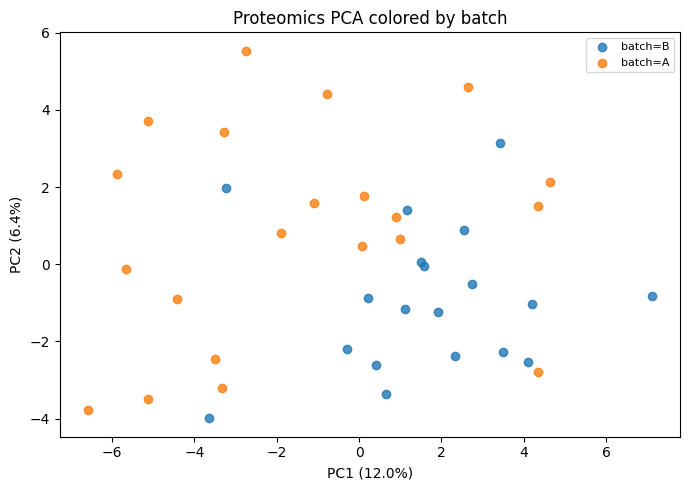

In [32]:
# PCA

def run_pca_plot_with_batch(
    mat,
    meta,
    title,
    outfile,
    color_by="batch",
    shape_by="timepoint"
):
    """
    PCA plot colored by batch (or any metadata column).
    mat: samples x features
    meta: metadata aligned to mat
    """

    # Keep only complete-case features for PCA
    mat2 = mat.loc[:, mat.notna().all(axis=0)]
    print(f"PCA ({title}): using {mat2.shape[1]} features")

    X = StandardScaler().fit_transform(mat2.values)
    pca = PCA(n_components=2, random_state=0)
    pcs = pca.fit_transform(X)

    df = meta.copy()
    df["PC1"] = pcs[:, 0]
    df["PC2"] = pcs[:, 1]

    var = pca.explained_variance_ratio_

    plt.figure(figsize=(7, 5))
    for b in df[color_by].astype(str).unique():
        sub = df[df[color_by].astype(str) == b]
        plt.scatter(
            sub["PC1"],
            sub["PC2"],
            alpha=0.8,
            label=f"{color_by}={b}"
        )

    plt.title(title)
    plt.xlabel(f"PC1 ({var[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({var[1]*100:.1f}%)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

#plot
# RNA
run_pca_plot_with_batch(
    mat=rna_index,
    meta=meta,
    title="RNA PCA colored by batch",
    outfile="pca_rna_batch.png",
    color_by="batch"
)

# Proteomics
run_pca_plot_with_batch(
    mat=prot_index,
    meta=meta,
    title="Proteomics PCA colored by batch",
    outfile="pca_proteomics_batch.png",
    color_by="batch"
)






PCA (RNA PCA colored by treatment): using 500 features


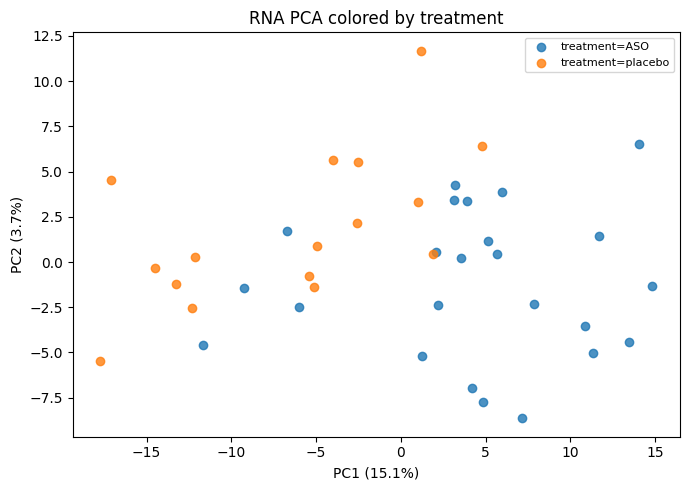

PCA (Proteomics PCA colored by treatment): using 96 features


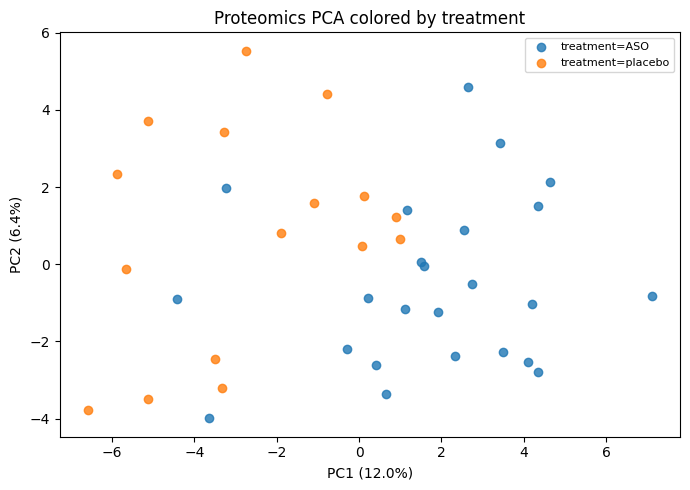

In [33]:
#plot
# RNA
run_pca_plot_with_batch(
    mat=rna_index,
    meta=meta,
    title="RNA PCA colored by treatment",
    outfile="pca_rna_treatment.png",
    color_by="treatment"
)

# Proteomics
run_pca_plot_with_batch(
    mat=prot_index,
    meta=meta,
    title="Proteomics PCA colored by treatment",
    outfile="pca_proteomics_treatment.png",
    color_by="treatment"
)

In [9]:
#prot.head()
rna.head()

,sample_id,GENE001,GENE002,GENE003,GENE004,GENE005,GENE006,GENE007,GENE008,GENE009,...,GENE491,GENE492,GENE493,GENE494,GENE495,GENE496,GENE497,GENE498,GENE499,GENE500
0,SUBJ001_baseline,1.400642,2.735238,1.513539,0.382144,0.803654,-1.387926,0.697304,0.530930,-0.783429,...,0.103165,0.629301,0.355733,0.859619,-0.647626,1.223826,-0.171659,1.452532,-0.125823,-0.108465
1,SUBJ001_week4,-1.509614,-0.092412,2.127374,-1.813343,-0.025254,0.944700,-0.701907,-1.040109,-1.015333,...,0.260129,0.032911,0.807487,-0.238872,1.407025,0.374677,0.278052,1.242531,0.256335,1.502989
2,SUBJ002_baseline,0.751584,-1.562812,0.881252,-1.690045,0.943572,1.800349,0.646826,-2.384989,0.835557,...,-0.355140,-1.105194,-0.755294,-0.740338,-0.485549,-0.957463,-1.039222,0.706301,0.821646,-1.608552
3,SUBJ002_week4,-2.978597,0.803357,-1.434913,-0.069792,-1.808492,1.070305,2.365557,-0.025534,-0.335062,...,-0.379778,0.139719,0.087304,1.514651,-0.067869,-0.606891,0.237313,-0.055302,-1.799513,-0.257649
4,SUBJ003_baseline,-0.023045,-0.466179,1.113276,-0.707986,0.533312,-0.070164,0.185388,0.489479,-1.229881,...,0.743277,0.775006,-0.563766,0.532707,-0.111702,-1.409541,-0.483914,-1.485997,1.057787,0.433583


In [34]:
# check gen001 prot001

def extract_feature_long(mat: pd.DataFrame, meta: pd.DataFrame, feature_id: str, layer: str) -> pd.DataFrame:
    if feature_id not in mat.columns:
        raise KeyError(f"{layer} feature not found: {feature_id}")

    df = meta[["sample_id", "subject_id", "treatment", "timepoint"]].copy()
    df["value"] = pd.to_numeric(mat[feature_id].values, errors="coerce")
    df["feature"] = feature_id
    df["layer"] = layer
    return df

def plot_expression_by_group(df_long: pd.DataFrame, title: str, outfile: str):
    df = df_long.copy()
    df["group"] = df["treatment"].astype(str) + " / " + df["timepoint"].astype(str)

    groups = [g for g in df["group"].unique() if "nan" not in g.lower()]
    groups_sorted = sorted(groups)

    data = [df.loc[df["group"] == g, "value"].dropna().values for g in groups_sorted]

    plt.figure(figsize=(9, 4))
    plt.boxplot(data, labels=groups_sorted, showfliers=False)
    for i, vals in enumerate(data, start=1):
        x = np.random.normal(i, 0.04, size=len(vals))
        plt.scatter(x, vals, alpha=0.75)

    plt.title(title)
    plt.ylabel("Expression (transformed)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.close()
    print("Saved:", outfile)

def plot_spaghetti(df_long: pd.DataFrame, title: str, outfile: str):
    df = df_long.copy()
    df = df[df["timepoint"].isin([BASELINE_LABEL, WEEK4_LABEL])]

    treatments = [t for t in ["placebo", "ASO"] if t in df["treatment"].astype(str).unique()]
    fig, axes = plt.subplots(1, len(treatments), figsize=(6*len(treatments), 4), sharey=True)
    if len(treatments) == 1:
        axes = [axes]

    for ax, tr in zip(axes, treatments):
        sub = df[df["treatment"].astype(str) == tr]
        for sid, g in sub.groupby("subject_id"):
            g2 = g.sort_values("timepoint")
            ax.plot(g2["timepoint"].astype(str), g2["value"], alpha=0.5)
            ax.scatter(g2["timepoint"].astype(str), g2["value"], s=25, alpha=0.9)
        ax.set_title(f"{title} ({tr})")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Expression (transformed)")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.close()
    print("Saved:", outfile)

def compute_subject_delta(df_long: pd.DataFrame) -> pd.DataFrame:
    wide = (
        df_long.pivot_table(
            index=["subject_id", "treatment"],
            columns="timepoint",
            values="value",
            aggfunc="mean",
        )
        .reset_index()
    )
    if BASELINE_LABEL not in wide.columns:
        wide[BASELINE_LABEL] = np.nan
    if WEEK4_LABEL not in wide.columns:
        wide[WEEK4_LABEL] = np.nan
    wide["delta"] = wide[WEEK4_LABEL] - wide[BASELINE_LABEL]
    return wide

def compare_deltas(delta_df: pd.DataFrame, label: str):
    print(f"\n>>> Delta comparison: {label}")
    print(delta_df.groupby("treatment")["delta"].agg(["count","mean","std"]))

    a = delta_df.loc[delta_df["treatment"].astype(str) == "ASO", "delta"].dropna().values
    p = delta_df.loc[delta_df["treatment"].astype(str) == "placebo", "delta"].dropna().values
    if len(a) >= 2 and len(p) >= 2:
        t = stats.ttest_ind(a, p, equal_var=False)
        w = stats.mannwhitneyu(a, p, alternative="two-sided")
        print(f"Welch t-test p={t.pvalue:.4g}")
        print(f"Mann–Whitney p={w.pvalue:.4g}")
    else:
        print("[WARN] Not enough data for tests.")



In [40]:
# check expt in RNA eset
GENE_OF_INTEREST = "GENE001"
BASELINE_LABEL = "baseline"
WEEK4_LABEL = "week4"


if GENE_OF_INTEREST in rna_index.columns:
    gene_df = extract_feature_long(rna_index, meta, GENE_OF_INTEREST, "RNA(log2CPM)")
    print(gene_df.head(10))

    gene_df.to_csv(os.path.join( f"{GENE_OF_INTEREST}_rna_long.csv"), index=False)
    print(f"Saved: {GENE_OF_INTEREST}_rna_long.csv")

    plot_expression_by_group(
        gene_df,
        title=f"{GENE_OF_INTEREST} RNA expression (log2CPM)",
        outfile=os.path.join( f"{GENE_OF_INTEREST}_rna_by_group.png"),
    )
    plot_spaghetti(
        gene_df,
        title=f"{GENE_OF_INTEREST} RNA spaghetti",
        outfile=os.path.join( f"{GENE_OF_INTEREST}_rna_spaghetti.png"),
    )

    gene_delta = compute_subject_delta(gene_df)
    print("\nGENE001 deltas preview:")
    print(gene_delta.head(10))

    gene_delta.to_csv(os.path.join( f"{GENE_OF_INTEREST}_rna_deltas.csv"), index=False)
    print(f"Saved: {GENE_OF_INTEREST}_rna_deltas.csv")

    compare_deltas(gene_delta, f"{GENE_OF_INTEREST} (RNA log2CPM) Δweek4-baseline")
else:
    print(f"[WARN] {GENE_OF_INTEREST} not found in RNA matrix columns.")


          sample_id subject_id treatment timepoint     value  feature  \
0  SUBJ001_baseline    SUBJ001       ASO  baseline  1.400642  GENE001   
1     SUBJ001_week4    SUBJ001       ASO     week4 -1.509614  GENE001   
2  SUBJ002_baseline    SUBJ002   placebo  baseline  0.751584  GENE001   
3     SUBJ002_week4    SUBJ002   placebo     week4 -2.978597  GENE001   
4  SUBJ003_baseline    SUBJ003   placebo  baseline -0.023045  GENE001   
5     SUBJ003_week4    SUBJ003   placebo     week4 -0.238737  GENE001   
6  SUBJ004_baseline    SUBJ004       ASO  baseline  0.385884  GENE001   
7     SUBJ004_week4    SUBJ004       ASO     week4 -4.208416  GENE001   
8  SUBJ005_baseline    SUBJ005       ASO  baseline  0.984681  GENE001   
9     SUBJ005_week4    SUBJ005       ASO     week4 -1.940487  GENE001   

          layer  
0  RNA(log2CPM)  
1  RNA(log2CPM)  
2  RNA(log2CPM)  
3  RNA(log2CPM)  
4  RNA(log2CPM)  
5  RNA(log2CPM)  
6  RNA(log2CPM)  
7  RNA(log2CPM)  
8  RNA(log2CPM)  
9  RNA(log2CPM) 

/tmp/ipykernel_6402/3482527384.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups_sorted, showfliers=False)


Saved: GENE001_rna_by_group.png
Saved: GENE001_rna_spaghetti.png

GENE001 deltas preview:
timepoint subject_id treatment  baseline     week4     delta
0            SUBJ001       ASO  1.400642 -1.509614 -2.910256
1            SUBJ002   placebo  0.751584 -2.978597 -3.730182
2            SUBJ003   placebo -0.023045 -0.238737 -0.215692
3            SUBJ004       ASO  0.385884 -4.208416 -4.594300
4            SUBJ005       ASO  0.984681 -1.940487 -2.925169
5            SUBJ006       ASO  0.443666 -3.763849 -4.207515
6            SUBJ007       ASO  1.800832 -2.555809 -4.356641
7            SUBJ008       ASO  0.687747 -2.263513 -2.951260
8            SUBJ009   placebo -1.436808 -1.304630  0.132178
9            SUBJ010   placebo -0.952928  0.666074  1.619003
Saved: GENE001_rna_deltas.csv

>>> Delta comparison: GENE001 (RNA log2CPM) Δweek4-baseline
           count      mean       std
treatment                           
ASO           12 -3.291949  1.310032
placebo        8 -0.514468  1.680824
